In [1]:
#🔹 CELL 1 — Setup & Path
import os
import json
import glob
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

BASE_DIR = "/kaggle/input/datasets/agungpambudi/secure-intrusion-detection-ddos-attacks-profiling/ddos-attacks-profiling"
if not os.path.exists(BASE_DIR):
    BASE_DIR = "ddos-attacks-profiling"

RAW_DIR  = os.path.join(BASE_DIR, "Raw_Data")
PROC_DIR = os.path.join(BASE_DIR, "Processed_Data")

ID_SCENARIO = "Correct_ID"
RANDOM_CS   = "Random_CS_Off"
GAUSSIAN    = "Gaussian_Off"
TRAFFIC     = "Attack"

scenario_path      = os.path.join(RAW_DIR, ID_SCENARIO, RANDOM_CS, GAUSSIAN, TRAFFIC)
proc_scenario_path = os.path.join(PROC_DIR, ID_SCENARIO, RANDOM_CS, GAUSSIAN)

print("Raw exists:", os.path.exists(RAW_DIR))
print("Scenario exists:", os.path.exists(scenario_path))

Raw exists: True
Scenario exists: True


In [2]:
#🔹 CELL 2 — Build Event Table
auth_df      = pd.read_csv(os.path.join(scenario_path, "authentication_results.csv"))
ev_install_df = pd.read_csv(os.path.join(scenario_path, "ev_installation.csv"))

event_table = auth_df.merge(ev_install_df, on="Session ID", how="left", suffixes=("", "_ev"))
if "CS Id" in event_table.columns:
    event_table = event_table.drop(columns=["CS Id"])
if "Installation_ev" in event_table.columns:
    event_table = event_table.rename(columns={"Installation_ev": "EV_Installation_Flag"})

cs_id_pid_df = pd.read_csv(os.path.join(scenario_path, "cs_id_pid.csv"))
event_table  = event_table.merge(cs_id_pid_df, on="CS ID", how="left")

cs_install_df = pd.read_csv(os.path.join(scenario_path, "cs_installation.csv"))
cs_install_df["CS_Was_Installed"] = True
event_table = event_table.merge(cs_install_df, on="CS ID", how="left")
event_table["CS_Was_Installed"] = event_table["CS_Was_Installed"].fillna(False)

acn_df = pd.read_csv(os.path.join(scenario_path, "acn_data.csv"))
acn_station_summary = acn_df.groupby("stationID").agg(
    ACN_avg_kWhDelivered=("kWhDelivered", "mean"),
    ACN_total_sessions=("sessionID", "count"),
).reset_index().rename(columns={"stationID": "CS ID"})
event_table = event_table.merge(acn_station_summary, on="CS ID", how="left")

event_table["ID_Scenario"]         = ID_SCENARIO
event_table["Random_CS_Config"]    = RANDOM_CS
event_table["Gaussian_Config"]     = GAUSSIAN
event_table["Traffic_Type_Folder"] = TRAFFIC

print("✅ event_table ready!")
print("Shape:", event_table.shape)
display(event_table.head())

✅ event_table ready!
Shape: (111284, 19)


,Session ID,CS ID,Timestamp,Authentication,Installation,Type,Date_Time,Process Order,HEX EV ID,HEX Key,EV_Installation_Flag,CS PID,CS_Was_Installed,ACN_avg_kWhDelivered,ACN_total_sessions,ID_Scenario,Random_CS_Config,Gaussian_Config,Traffic_Type_Folder
0,5e44a6aef9af8b20e5250354,2-39-126-560,fresh,True,True,normal,2023-01-17 00:42:45.699746,654,0ca957b617d5c757cc251016837f11f0d76acfafaae4a5...,e7066c74355959b3dd38dcf5dc9fcf6fc84f47cd94989a...,True,1362420,True,7.032083,12,Correct_ID,Random_CS_Off,Gaussian_Off,Attack
1,5e7e9a9bf9af8b1be143ed74,2-39-126-560,fresh,True,True,normal,2023-01-17 00:42:45.746531,660,edbff329936820afcb0043988cbe312919a67ebfc24bcb...,69516d6f79eb91b06658862d7bffe4061177cfebcc5cad...,True,1362420,True,7.032083,12,Correct_ID,Random_CS_Off,Gaussian_Off,Attack
2,5e095332f9af8b6b70d5c4a6,2-39-126-560,fresh,True,True,normal,2023-01-17 00:42:45.814037,652,f84ef719852a46addf0cd9a3bd4c0063ab28d6fb0b0567...,62b74153df4d41659dd2131838d74d8d233141be6a7350...,True,1362420,True,7.032083,12,Correct_ID,Random_CS_Off,Gaussian_Off,Attack
3,5e45f835f9af8b24b31daa6b,2-39-126-560,fresh,True,True,normal,2023-01-17 00:42:45.884205,656,42dea0cdc5186dc6fec759131fb1d1a86489a0bd5277f6...,bbef939cc8b5da0402fef30c06e0b1927947f07d7241d0...,True,1362420,True,7.032083,12,Correct_ID,Random_CS_Off,Gaussian_Off,Attack
4,5eb74b0bf9af8b3dfb27c4b4,2-39-126-560,fresh,True,True,normal,2023-01-17 00:42:46.031090,661,a4ee17f07e6e0497b7b10d06ab766447b952d4ecc2c2dc...,04befebac1bdb907fb92a54daa75d7d4ecb65158ca0bfd...,True,1362420,True,7.032083,12,Correct_ID,Random_CS_Off,Gaussian_Off,Attack


In [3]:
#🔹 CELL 3 — Prepare Features & Target
df_ml = event_table.copy()

drop_cols = [
    "Session ID", "HEX EV ID", "HEX Key", "Date_Time",
    "CS ID", "ID_Scenario", "Random_CS_Config",
    "Gaussian_Config", "Traffic_Type_Folder",
    "Authentication", "Installation",
    "EV_Installation_Flag", "CS_Was_Installed",
    "Type",
]
df_ml = df_ml.drop(columns=[c for c in drop_cols if c in df_ml.columns])

df_ml["Label"]     = (event_table["Type"] == "attack").astype(int)
df_ml["Timestamp"] = (df_ml["Timestamp"] == "fresh").astype(int)
df_ml["CS PID"]    = pd.to_numeric(df_ml["CS PID"], errors="coerce").fillna(0)
df_ml["Process Order"] = pd.to_numeric(df_ml["Process Order"], errors="coerce").fillna(0)

for col in list(df_ml.columns):
    pct = df_ml[col].isnull().sum() / len(df_ml) * 100
    if pct > 50:
        df_ml = df_ml.drop(columns=[col])
    elif pct > 0:
        df_ml[col] = df_ml[col].fillna(round(df_ml[col].mean(), 2))

print("✅ df_ml ready!")
print("Shape:", df_ml.shape)
print("\nLabel distribution:")
print(df_ml["Label"].value_counts())
print("\nFeature columns:")
print(df_ml.drop(columns=["Label"]).columns.tolist())
display(df_ml.head())

✅ df_ml ready!
Shape: (111284, 6)

Label distribution:
Label
1    106000
0      5284
Name: count, dtype: int64

Feature columns:
['Timestamp', 'Process Order', 'CS PID', 'ACN_avg_kWhDelivered', 'ACN_total_sessions']


,Timestamp,Process Order,CS PID,ACN_avg_kWhDelivered,ACN_total_sessions,Label
0,1,654,1362420,7.032083,12,0
1,1,660,1362420,7.032083,12,0
2,1,652,1362420,7.032083,12,0
3,1,656,1362420,7.032083,12,0
4,1,661,1362420,7.032083,12,0


In [4]:
#🔹 CELL 4 — Feature Scaling & Train-Test Split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df_ml.drop(columns=["Label"])
y = df_ml["Label"]

feature_names = X.columns.tolist()

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("✅ Split ready!")
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("\ny_train distribution:")
print(pd.Series(y_train).value_counts())

✅ Split ready!
X_train: (89027, 5)
X_test:  (22257, 5)

y_train distribution:
Label
1    84800
0     4227
Name: count, dtype: int64


In [5]:
#🔹 CELL 5 — Import ML Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping

print("✅ All imports done!")

✅ All imports done!


=== Random Forest Training ===
✅ Random Forest Accuracy: 99.88%

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99      1057
      Attack       1.00      1.00      1.00     21200

    accuracy                           1.00     22257
   macro avg       1.00      0.99      0.99     22257
weighted avg       1.00      1.00      1.00     22257



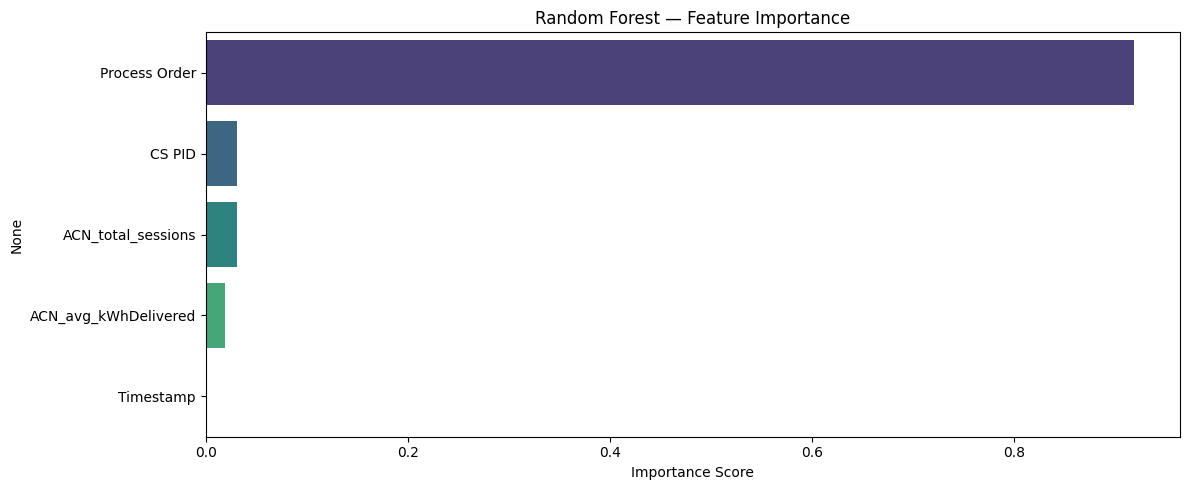


Feature Importances:
Process Order           0.918262
CS PID                  0.031425
ACN_total_sessions      0.030942
ACN_avg_kWhDelivered    0.018970
Timestamp               0.000402
dtype: float64


In [6]:
#🔹 CELL 6 — Random Forest Training
print("=== Random Forest Training ===")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rf_acc    = accuracy_score(y_test, y_pred_rf)

print(f"✅ Random Forest Accuracy: {rf_acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=["Normal", "Attack"]))

importances = pd.Series(
    rf_model.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nFeature Importances:")
print(importances)

In [7]:
#🔹 CELL 7 — Feature Selection (RF → CNN)
print("=== Top Feature Selection for CNN ===")

TOP_N        = min(5, len(feature_names))
top_features = importances.head(TOP_N).index.tolist()

print(f"Selected top {TOP_N} features:")
for i, f in enumerate(top_features):
    print(f"  {i+1}. {f} (importance: {importances[f]:.4f})")

feat_idx    = [feature_names.index(f) for f in top_features]
X_train_top = X_train[:, feat_idx]
X_test_top  = X_test[:, feat_idx]

X_train_cnn = X_train_top.reshape(X_train_top.shape[0], X_train_top.shape[1], 1)
X_test_cnn  = X_test_top.reshape(X_test_top.shape[0],  X_test_top.shape[1],  1)

print(f"\nX_train_cnn: {X_train_cnn.shape}")
print(f"X_test_cnn:  {X_test_cnn.shape}")

=== Top Feature Selection for CNN ===
Selected top 5 features:
  1. Process Order (importance: 0.9183)
  2. CS PID (importance: 0.0314)
  3. ACN_total_sessions (importance: 0.0309)
  4. ACN_avg_kWhDelivered (importance: 0.0190)
  5. Timestamp (importance: 0.0004)

X_train_cnn: (89027, 5, 1)
X_test_cnn:  (22257, 5, 1)


In [8]:
print("X_train_cnn exists:", 'X_train_cnn' in dir())
print("X_train exists:", 'X_train' in dir())
print("y_train exists:", 'y_train' in dir())

X_train_cnn exists: True
X_train exists: True
y_train exists: True


All libraries loaded successfully!
Before SMOTE:
  Attack : 84800
  Normal : 4227
After SMOTE:
  Attack : 84800
  Normal : 84800


I0000 00:00:1786691741.772222      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786691741.776836      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Starting Hyperparameter Search - trying 10 combinations...


I0000 00:00:1786691751.940692     102 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Best Hyperparameters Found:
  filters_1     : 64
  filters_2     : 128
  dense_units   : 64
  dropout_1     : 0.4
  dropout_2     : 0.2
  dropout_3     : 0.4
  learning_rate : 0.0001

Training Final CNN with Best Hyperparameters...
Epoch 1/100
597/597 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.5787 - loss: 0.7536 - val_accuracy: 0.2717 - val_loss: 0.8119 - learning_rate: 1.0000e-04
Epoch 2/100
597/597 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6009 - loss: 0.6422 - val_accuracy: 0.4194 - val_loss: 0.7604 - learning_rate: 1.0000e-04
Epoch 3/100
597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6123 - loss: 0.6235 - val_accuracy: 0.5293 - val_loss: 0.7208 - learning_rate: 1.0000e-04
Epoch 4/100
597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6180 - loss: 0.6163 - val_accuracy: 0.6283 - val_loss: 0.6946 - learning_rate: 1.0000e-04
Epoch 5/100
597/597 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6205 - loss: 0.6117 - val_accuracy: 0.6292 - val_loss: 0.6900 - learni

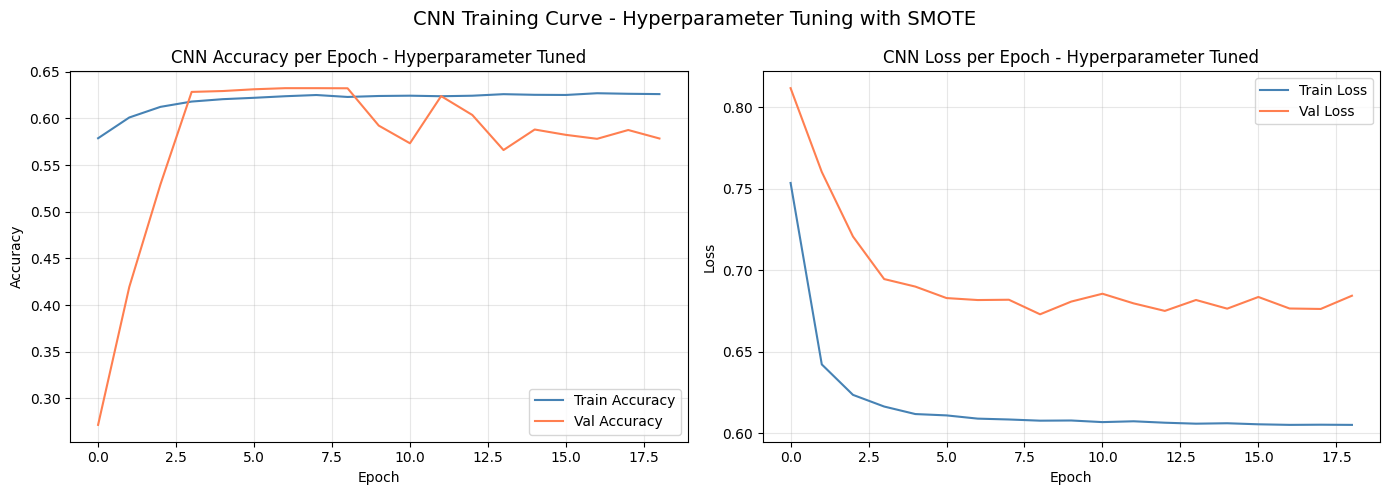

CNN Hyperparameter Tuning Complete!


In [9]:
# CELL 8 - CNN Model with Hyperparameter Tuning and SMOTE Balancing

# Install required libraries
import subprocess
subprocess.run(["pip", "install", "keras-tuner", "-q"])
subprocess.run(["pip", "install", "imbalanced-learn", "-q"])

import numpy as np
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, Dense, Dropout,
                                     BatchNormalization, Flatten)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

print("All libraries loaded successfully!")

# --------------------------------------------------
# Step 1: Apply SMOTE to balance the dataset
# Attack = 95%, Normal = 5% (severe imbalance)
# SMOTE creates synthetic Normal samples to balance
# --------------------------------------------------
sm = SMOTE(random_state=42)
X_train_sm_flat, y_train_sm = sm.fit_resample(
    X_train_cnn.reshape(X_train_cnn.shape[0], -1), y_train)

n_features = X_train_cnn.shape[1]
X_train_sm_cnn = X_train_sm_flat.reshape(
    X_train_sm_flat.shape[0], n_features, 1)

print("Before SMOTE:")
print(f"  Attack : {(y_train==1).sum()}")
print(f"  Normal : {(y_train==0).sum()}")
print("After SMOTE:")
print(f"  Attack : {(y_train_sm==1).sum()}")
print(f"  Normal : {(y_train_sm==0).sum()}")

# --------------------------------------------------
# Step 2: Define hyperparameter search space
# Keras Tuner will try different combinations
# to find the best model configuration
# --------------------------------------------------
def build_model(hp):
    model = Sequential()

    # First Conv layer - tune number of filters
    model.add(Conv1D(
        filters=hp.Choice("filters_1", [32, 64, 128]),
        kernel_size=1,
        activation="relu",
        padding="same",
        input_shape=(n_features, 1)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_1", 0.1, 0.5, step=0.1)))

    # Second Conv layer - tune number of filters
    model.add(Conv1D(
        filters=hp.Choice("filters_2", [64, 128, 256]),
        kernel_size=1,
        activation="relu",
        padding="same"
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_2", 0.1, 0.5, step=0.1)))

    # Flatten layer to convert 2D to 1D for Dense layer
    model.add(Flatten())

    # Dense layer - tune number of units
    model.add(Dense(
        units=hp.Choice("dense_units", [64, 128, 256]),
        activation="relu"
    ))
    model.add(Dropout(hp.Float("dropout_3", 0.1, 0.4, step=0.1)))

    # Output layer - sigmoid for binary classification
    # Output > 0.5 = Attack, Output < 0.5 = Normal
    model.add(Dense(1, activation="sigmoid"))

    # Compile model - tune learning rate
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice(
                "learning_rate", [0.001, 0.0001, 0.00001])
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# --------------------------------------------------
# Step 3: Run Keras Tuner Random Search
# Tries 10 different hyperparameter combinations
# Selects the one with best validation accuracy
# --------------------------------------------------
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=10,
    executions_per_trial=1,
    directory="tuner_results",
    project_name="ddos_cnn",
    overwrite=True
)

print("Starting Hyperparameter Search - trying 10 combinations...")
tuner.search(
    X_train_sm_cnn, y_train_sm,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3)],
    verbose=0
)

# Print best hyperparameters found
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nBest Hyperparameters Found:")
print(f"  filters_1     : {best_hps.get('filters_1')}")
print(f"  filters_2     : {best_hps.get('filters_2')}")
print(f"  dense_units   : {best_hps.get('dense_units')}")
print(f"  dropout_1     : {best_hps.get('dropout_1')}")
print(f"  dropout_2     : {best_hps.get('dropout_2')}")
print(f"  dropout_3     : {best_hps.get('dropout_3')}")
print(f"  learning_rate : {best_hps.get('learning_rate')}")

# --------------------------------------------------
# Step 4: Train final CNN with best hyperparameters
# Full training with 100 epochs and callbacks
# --------------------------------------------------
print("\nTraining Final CNN with Best Hyperparameters...")
cnn_model = tuner.hypermodel.build(best_hps)

# Stop training if validation loss does not improve
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Reduce learning rate if training gets stuck
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=0.000001,
    verbose=1
)

history = cnn_model.fit(
    X_train_sm_cnn, y_train_sm,
    epochs=100,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# --------------------------------------------------
# Step 5: Plot training curves
# Accuracy and Loss per epoch
# Shows if model is learning properly
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy curve
axes[0].plot(history.history["accuracy"],
             label="Train Accuracy", color="steelblue")
axes[0].plot(history.history["val_accuracy"],
             label="Val Accuracy", color="coral")
axes[0].set_title("CNN Accuracy per Epoch - Hyperparameter Tuned")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss curve
axes[1].plot(history.history["loss"],
             label="Train Loss", color="steelblue")
axes[1].plot(history.history["val_loss"],
             label="Val Loss", color="coral")
axes[1].set_title("CNN Loss per Epoch - Hyperparameter Tuned")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("CNN Training Curve - Hyperparameter Tuning with SMOTE",
             fontsize=14)
plt.tight_layout()
plt.show()

print("CNN Hyperparameter Tuning Complete!")

=== STEP 4: Model Evaluation ===
696/696 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
✅ Random Forest Accuracy : 99.88%
✅ CNN Accuracy           : 61.75%

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99      1057
      Attack       1.00      1.00      1.00     21200

    accuracy                           1.00     22257
   macro avg       1.00      0.99      0.99     22257
weighted avg       1.00      1.00      1.00     22257


=== RF+CNN Hybrid Classification Report ===
              precision    recall  f1-score   support

      Normal       0.08      0.66      0.14      1057
      Attack       0.97      0.62      0.75     21200

    accuracy                           0.62     22257
   macro avg       0.53      0.64      0.45     22257
weighted avg       0.93      0.62      0.72     22257



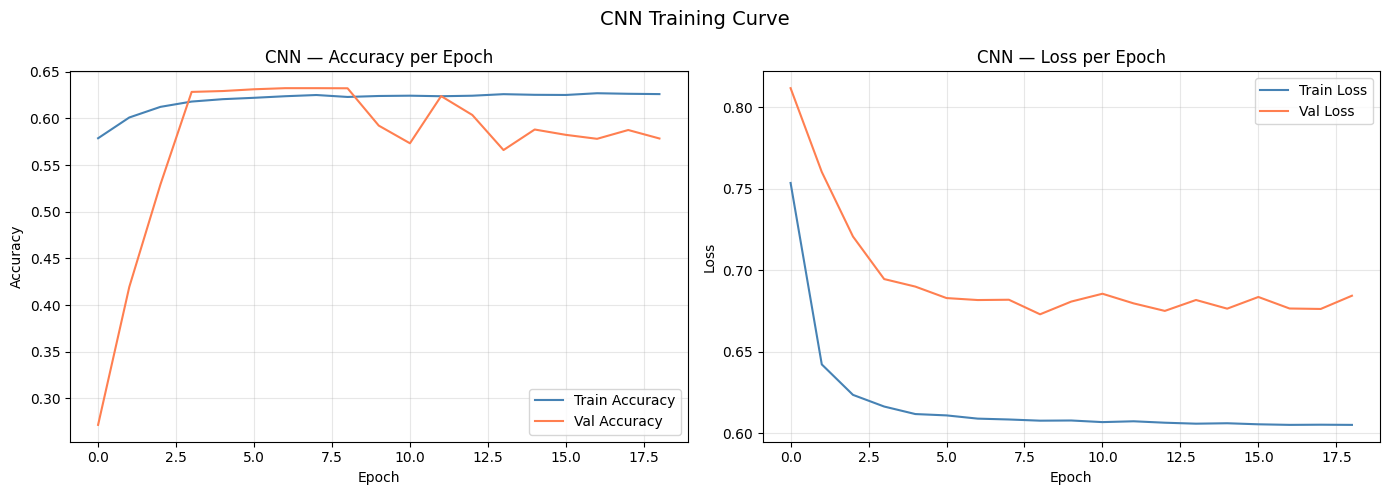

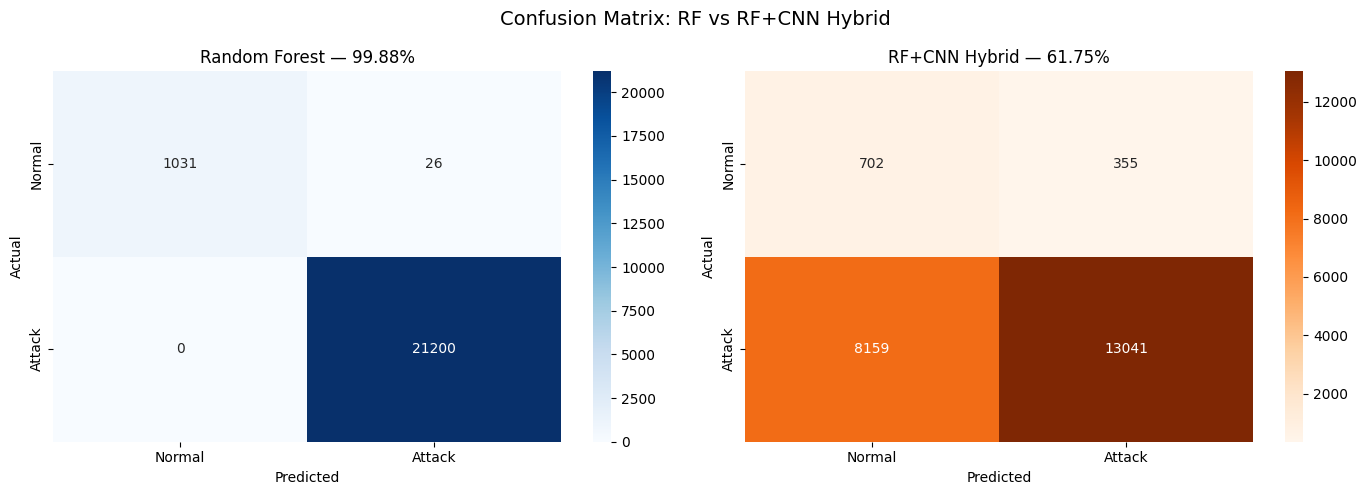


=== Confusion Matrix Values (RF+CNN) ===
True Negative  (Normal → Normal) : 702
False Positive (Normal → Attack) : 355
False Negative (Attack → Normal) : 8159
True Positive  (Attack → Attack) : 13041


In [10]:
#🔹 CELL 9 — Model Evaluation & Confusion Matrix
print("=== STEP 4: Model Evaluation ===")

# CNN prediction
y_pred_cnn_prob = cnn_model.predict(X_test_cnn).flatten()
y_pred_cnn      = (y_pred_cnn_prob >= 0.5).astype(int)
cnn_acc         = accuracy_score(y_test, y_pred_cnn)
rf_acc          = accuracy_score(y_test, y_pred_rf)

print(f"✅ Random Forest Accuracy : {rf_acc  * 100:.2f}%")
print(f"✅ CNN Accuracy           : {cnn_acc * 100:.2f}%")

print("\n=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf,
      target_names=["Normal", "Attack"]))

print("\n=== RF+CNN Hybrid Classification Report ===")
print(classification_report(y_test, y_pred_cnn,
      target_names=["Normal", "Attack"]))

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"],
             label="Train Accuracy", color="steelblue")
axes[0].plot(history.history["val_accuracy"],
             label="Val Accuracy",   color="coral")
axes[0].set_title("CNN — Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["loss"],
             label="Train Loss", color="steelblue")
axes[1].plot(history.history["val_loss"],
             label="Val Loss",   color="coral")
axes[1].set_title("CNN — Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("CNN Training Curve", fontsize=14)
plt.tight_layout()
plt.show()

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            ax=axes[0],
            xticklabels=["Normal", "Attack"],
            yticklabels=["Normal", "Attack"])
axes[0].set_title(f"Random Forest — {rf_acc*100:.2f}%")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

cm_cnn = confusion_matrix(y_test, y_pred_cnn)
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Oranges",
            ax=axes[1],
            xticklabels=["Normal", "Attack"],
            yticklabels=["Normal", "Attack"])
axes[1].set_title(f"RF+CNN Hybrid — {cnn_acc*100:.2f}%")
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

plt.suptitle("Confusion Matrix: RF vs RF+CNN Hybrid", fontsize=14)
plt.tight_layout()
plt.show()

print("\n=== Confusion Matrix Values (RF+CNN) ===")
print(f"True Negative  (Normal → Normal) : {cm_cnn[0][0]}")
print(f"False Positive (Normal → Attack) : {cm_cnn[0][1]}")
print(f"False Negative (Attack → Normal) : {cm_cnn[1][0]}")
print(f"True Positive  (Attack → Attack) : {cm_cnn[1][1]}")

=== STEP 5: ROC Curve ===


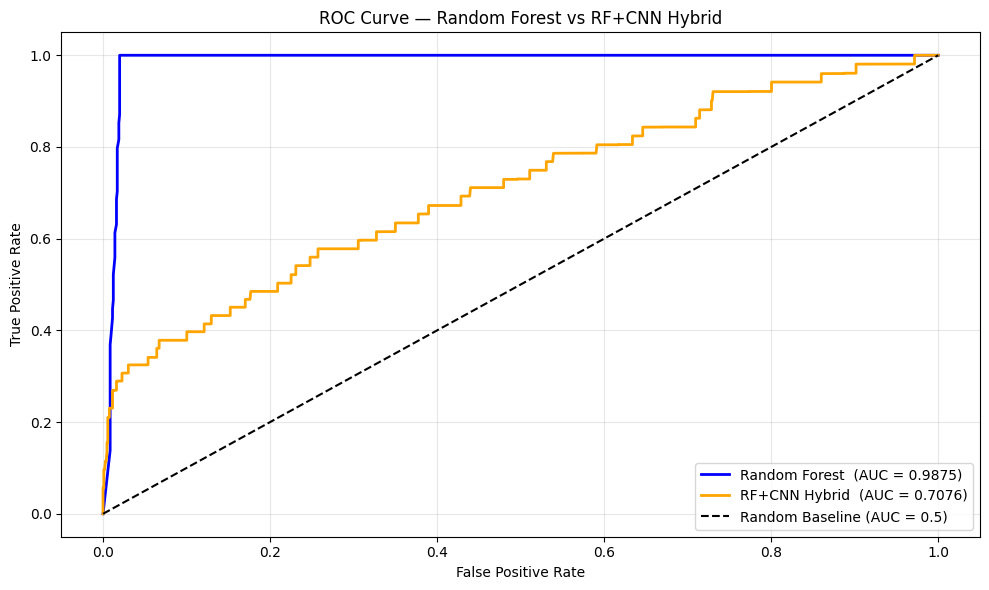

RF  AUC : 0.9875
CNN AUC : 0.7076


In [11]:
#🔹 CELL 10 — ROC Curve
print("=== STEP 5: ROC Curve ===")

rf_proba             = rf_model.predict_proba(X_test)[:, 1]
fpr_rf,  tpr_rf,  _  = roc_curve(y_test, rf_proba)
fpr_cnn, tpr_cnn, _  = roc_curve(y_test, y_pred_cnn_prob)
auc_rf               = roc_auc_score(y_test, rf_proba)
auc_cnn              = roc_auc_score(y_test, y_pred_cnn_prob)

plt.figure(figsize=(10, 6))
plt.plot(fpr_rf,  tpr_rf,
         label=f"Random Forest  (AUC = {auc_rf:.4f})",
         color="blue", linewidth=2)
plt.plot(fpr_cnn, tpr_cnn,
         label=f"RF+CNN Hybrid  (AUC = {auc_cnn:.4f})",
         color="orange", linewidth=2)
plt.plot([0, 1], [0, 1],
         "k--", label="Random Baseline (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest vs RF+CNN Hybrid")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"RF  AUC : {auc_rf:.4f}")
print(f"CNN AUC : {auc_cnn:.4f}")

In [12]:
#🔹 CELL 11 — Final Comparison & Save
print("=== FINAL MODEL COMPARISON ===")

results = pd.DataFrame({
    "Model": ["Random Forest", "RF + CNN Hybrid"],
    "Accuracy (%)": [
        round(rf_acc  * 100, 2),
        round(cnn_acc * 100, 2)
    ],
    "Precision": [
        round(precision_score(y_test, y_pred_rf),  4),
        round(precision_score(y_test, y_pred_cnn), 4)
    ],
    "Recall": [
        round(recall_score(y_test, y_pred_rf),  4),
        round(recall_score(y_test, y_pred_cnn), 4)
    ],
    "F1 Score": [
        round(f1_score(y_test, y_pred_rf),  4),
        round(f1_score(y_test, y_pred_cnn), 4)
    ],
    "AUC": [
        round(auc_rf,  4),
        round(auc_cnn, 4)
    ]
})

display(results)

output_dir = "/kaggle/working"
joblib.dump(rf_model, os.path.join(output_dir, "rf_model.pkl"))
cnn_model.save(os.path.join(output_dir, "cnn_model.keras"))

print("\n✅ Saved: rf_model.pkl + cnn_model.keras")
print("🎉 RF + CNN Hybrid Detection Complete!")

=== FINAL MODEL COMPARISON ===


,Model,Accuracy (%),Precision,Recall,F1 Score,AUC
0,Random Forest,99.88,0.9988,1.0000,0.9994,0.9875
1,RF + CNN Hybrid,61.75,0.9735,0.6151,0.7539,0.7076



✅ Saved: rf_model.pkl + cnn_model.keras
🎉 RF + CNN Hybrid Detection Complete!


OVERFITTING / UNDERFITTING ANALYSIS

=== Random Forest ===
Train Accuracy : 99.95%
Test  Accuracy : 99.88%
Difference     : 0.07%
✅ Status: GOOD FIT

=== CNN ===
Train Accuracy : 62.26%
Test  Accuracy : 61.75%
Train Loss     : 0.5525
Test  Loss     : 0.5498
Difference     : 0.52%
⚠️  Status: UNDERFIT


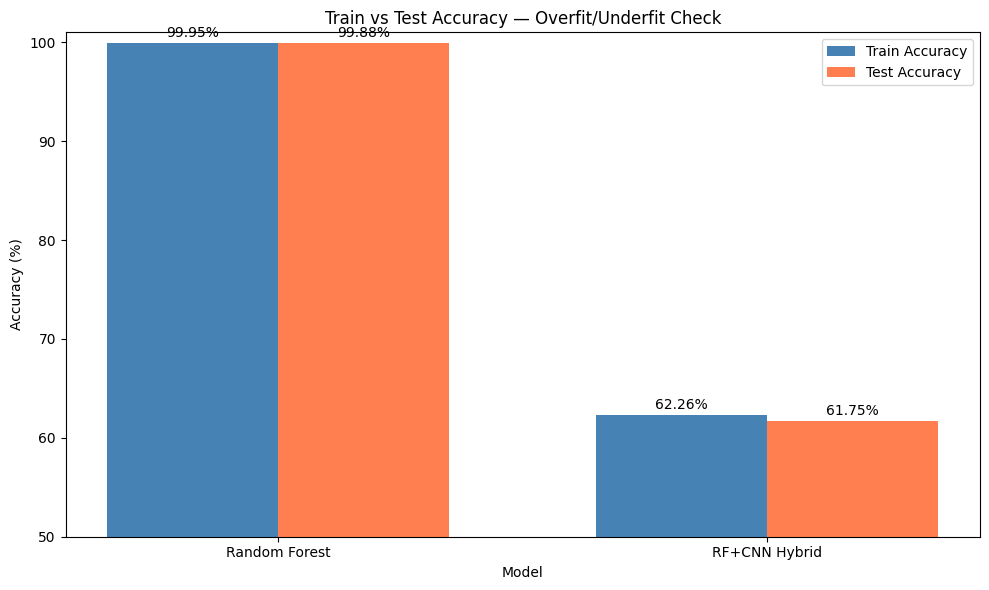


=== SUMMARY ===
RF  — Train: 99.95% | Test: 99.88% | Diff: 0.07%
CNN — Train: 62.26% | Test: 61.75% | Diff: 0.52%


In [13]:
#🔹 CELL 12 — Overfit/Underfit Analysis
print("=" * 60)
print("OVERFITTING / UNDERFITTING ANALYSIS")
print("=" * 60)

# RF Train vs Test
y_train_pred_rf = rf_model.predict(X_train)
rf_train_acc    = accuracy_score(y_train, y_train_pred_rf)
rf_test_acc     = accuracy_score(y_test,  y_pred_rf)
rf_diff         = rf_train_acc - rf_test_acc

print("\n=== Random Forest ===")
print(f"Train Accuracy : {rf_train_acc * 100:.2f}%")
print(f"Test  Accuracy : {rf_test_acc  * 100:.2f}%")
print(f"Difference     : {rf_diff      * 100:.2f}%")

if rf_diff > 0.05:
    print("⚠️  Status: OVERFIT")
elif rf_train_acc < 0.80 and rf_test_acc < 0.80:
    print("⚠️  Status: UNDERFIT")
else:
    print("✅ Status: GOOD FIT")

# CNN Train vs Test
cnn_train_loss, cnn_train_acc = cnn_model.evaluate(
    X_train_cnn, y_train, verbose=0)
cnn_test_loss,  cnn_test_acc  = cnn_model.evaluate(
    X_test_cnn,  y_test,  verbose=0)
cnn_diff = cnn_train_acc - cnn_test_acc

print("\n=== CNN ===")
print(f"Train Accuracy : {cnn_train_acc * 100:.2f}%")
print(f"Test  Accuracy : {cnn_test_acc  * 100:.2f}%")
print(f"Train Loss     : {cnn_train_loss:.4f}")
print(f"Test  Loss     : {cnn_test_loss:.4f}")
print(f"Difference     : {cnn_diff      * 100:.2f}%")

if cnn_diff > 0.05:
    print("⚠️  Status: OVERFIT")
elif cnn_train_acc < 0.80 and cnn_test_acc < 0.80:
    print("⚠️  Status: UNDERFIT")
else:
    print("✅ Status: GOOD FIT")

# Bar chart
import numpy as np
models    = ["Random Forest", "RF+CNN Hybrid"]
train_acc = [rf_train_acc * 100, cnn_train_acc * 100]
test_acc  = [rf_test_acc  * 100, cnn_test_acc  * 100]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, train_acc, width,
               label="Train Accuracy", color="steelblue")
bars2 = ax.bar(x + width/2, test_acc,  width,
               label="Test Accuracy",  color="coral")

ax.set_xlabel("Model")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Train vs Test Accuracy — Overfit/Underfit Check")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(50, 101)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{bar.get_height():.2f}%",
            ha="center", va="bottom", fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{bar.get_height():.2f}%",
            ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

print("\n=== SUMMARY ===")
print(f"RF  — Train: {rf_train_acc*100:.2f}% | Test: {rf_test_acc*100:.2f}% | Diff: {rf_diff*100:.2f}%")
print(f"CNN — Train: {cnn_train_acc*100:.2f}% | Test: {cnn_test_acc*100:.2f}% | Diff: {cnn_diff*100:.2f}%")

TRAINING DATA — MODEL PERFORMANCE REPORT

=== Random Forest (Training Data) ===
Accuracy  : 99.95%
Precision : 0.9995
Recall    : 1.0000
F1 Score  : 0.9997

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      4227
      Attack       1.00      1.00      1.00     84800

    accuracy                           1.00     89027
   macro avg       1.00      0.99      1.00     89027
weighted avg       1.00      1.00      1.00     89027



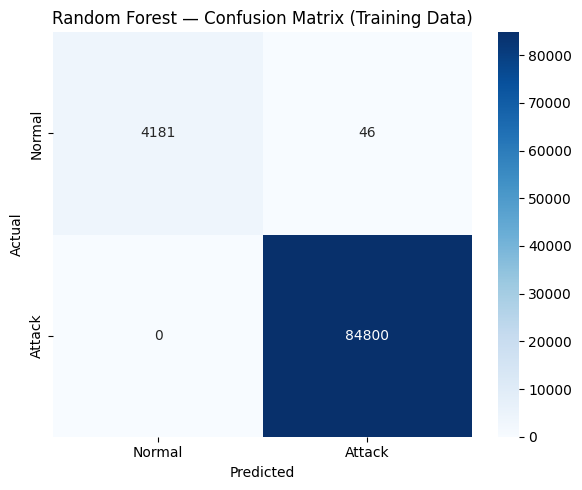


=== RF+CNN Hybrid (Training Data) ===
2783/2783 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
Accuracy  : 62.26%
Precision : 0.9710
Recall    : 0.6224
F1 Score  : 0.7586

Classification Report:
              precision    recall  f1-score   support

      Normal       0.08      0.63      0.14      4227
      Attack       0.97      0.62      0.76     84800

    accuracy                           0.62     89027
   macro avg       0.52      0.62      0.45     89027
weighted avg       0.93      0.62      0.73     89027



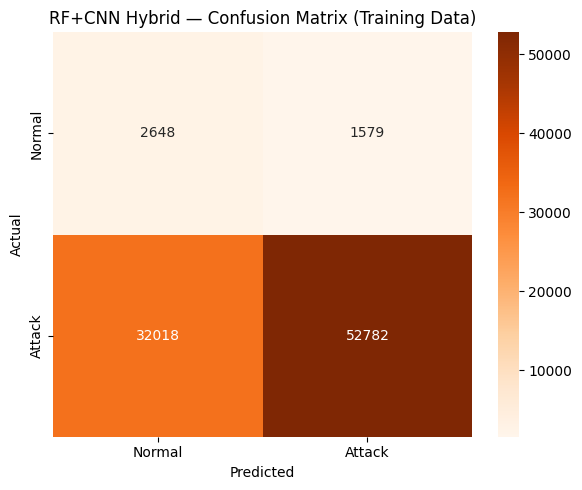


=== TRAINING DATA SUMMARY ===


,Model,Accuracy (%),Precision,Recall,F1 Score,Data
0,Random Forest,99.95,0.9995,1.0000,0.9997,Train
1,RF+CNN Hybrid,62.26,0.9710,0.6224,0.7586,Train


In [14]:
#🔹 CELL 13 — Train Data Report
print("=" * 60)
print("TRAINING DATA — MODEL PERFORMANCE REPORT")
print("=" * 60)

# RF Train
print("\n=== Random Forest (Training Data) ===")
y_train_pred_rf = rf_model.predict(X_train)
print(f"Accuracy  : {accuracy_score(y_train, y_train_pred_rf) * 100:.2f}%")
print(f"Precision : {precision_score(y_train, y_train_pred_rf, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_train, y_train_pred_rf, zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_train, y_train_pred_rf, zero_division=0):.4f}")
print("\nClassification Report:")
print(classification_report(y_train, y_train_pred_rf,
      target_names=["Normal", "Attack"], zero_division=0))

cm_rf_train = confusion_matrix(y_train, y_train_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf_train, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Attack"],
            yticklabels=["Normal", "Attack"])
plt.title("Random Forest — Confusion Matrix (Training Data)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# CNN Train
print("\n=== RF+CNN Hybrid (Training Data) ===")
y_train_pred_cnn_prob = cnn_model.predict(X_train_cnn).flatten()
y_train_pred_cnn      = (y_train_pred_cnn_prob >= 0.5).astype(int)
print(f"Accuracy  : {accuracy_score(y_train, y_train_pred_cnn) * 100:.2f}%")
print(f"Precision : {precision_score(y_train, y_train_pred_cnn, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_train, y_train_pred_cnn, zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_train, y_train_pred_cnn, zero_division=0):.4f}")
print("\nClassification Report:")
print(classification_report(y_train, y_train_pred_cnn,
      target_names=["Normal", "Attack"], zero_division=0))

cm_cnn_train = confusion_matrix(y_train, y_train_pred_cnn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_cnn_train, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Normal", "Attack"],
            yticklabels=["Normal", "Attack"])
plt.title("RF+CNN Hybrid — Confusion Matrix (Training Data)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# Train Summary
print("\n=== TRAINING DATA SUMMARY ===")
train_summary = pd.DataFrame({
    "Model": ["Random Forest", "RF+CNN Hybrid"],
    "Accuracy (%)": [
        round(accuracy_score(y_train, y_train_pred_rf)  * 100, 2),
        round(accuracy_score(y_train, y_train_pred_cnn) * 100, 2)
    ],
    "Precision": [
        round(precision_score(y_train, y_train_pred_rf,  zero_division=0), 4),
        round(precision_score(y_train, y_train_pred_cnn, zero_division=0), 4)
    ],
    "Recall": [
        round(recall_score(y_train, y_train_pred_rf,  zero_division=0), 4),
        round(recall_score(y_train, y_train_pred_cnn, zero_division=0), 4)
    ],
    "F1 Score": [
        round(f1_score(y_train, y_train_pred_rf,  zero_division=0), 4),
        round(f1_score(y_train, y_train_pred_cnn, zero_division=0), 4)
    ],
    "Data": ["Train", "Train"]
})
display(train_summary)

TEST DATA — MODEL PERFORMANCE REPORT

=== Random Forest (Test Data) ===
Accuracy  : 99.88%
Precision : 0.9988
Recall    : 1.0000
F1 Score  : 0.9994

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99      1057
      Attack       1.00      1.00      1.00     21200

    accuracy                           1.00     22257
   macro avg       1.00      0.99      0.99     22257
weighted avg       1.00      1.00      1.00     22257



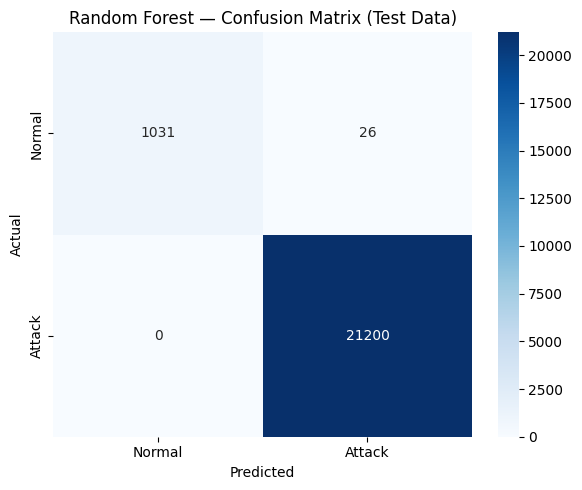


=== RF+CNN Hybrid (Test Data) ===
Accuracy  : 61.75%
Precision : 0.9735
Recall    : 0.6151
F1 Score  : 0.7539

Classification Report:
              precision    recall  f1-score   support

      Normal       0.08      0.66      0.14      1057
      Attack       0.97      0.62      0.75     21200

    accuracy                           0.62     22257
   macro avg       0.53      0.64      0.45     22257
weighted avg       0.93      0.62      0.72     22257



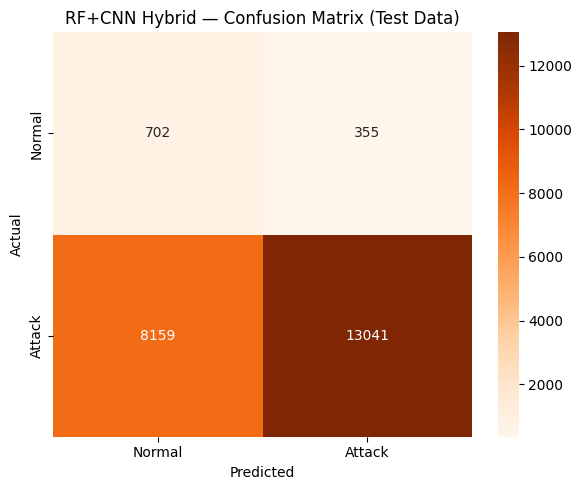


=== TEST DATA SUMMARY ===


,Model,Accuracy (%),Precision,Recall,F1 Score,Data
0,Random Forest,99.88,0.9988,1.0000,0.9994,Test
1,RF+CNN Hybrid,61.75,0.9735,0.6151,0.7539,Test



=== FINAL: TRAIN vs TEST COMPARISON ===


,Model,Accuracy (%),Recall,F1 Score,Status
0,RF (Train),99.95,1.0000,0.9997,Train
1,RF (Test),99.88,1.0000,0.9994,Test
2,CNN (Train),62.26,0.6224,0.7586,Train
3,CNN (Test),61.75,0.6151,0.7539,Test


In [15]:
#CELL 14 — Test Data Report
print("=" * 60)
print("TEST DATA — MODEL PERFORMANCE REPORT")
print("=" * 60)

# RF Test
print("\n=== Random Forest (Test Data) ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_rf, zero_division=0):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=["Normal", "Attack"], zero_division=0))

cm_rf_test = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf_test, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Attack"],
            yticklabels=["Normal", "Attack"])
plt.title("Random Forest — Confusion Matrix (Test Data)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# CNN Test
print("\n=== RF+CNN Hybrid (Test Data) ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_cnn) * 100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred_cnn, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_cnn, zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_cnn, zero_division=0):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cnn,
      target_names=["Normal", "Attack"], zero_division=0))

cm_cnn_test = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_cnn_test, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Normal", "Attack"],
            yticklabels=["Normal", "Attack"])
plt.title("RF+CNN Hybrid — Confusion Matrix (Test Data)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# Test Summary
print("\n=== TEST DATA SUMMARY ===")
test_summary = pd.DataFrame({
    "Model": ["Random Forest", "RF+CNN Hybrid"],
    "Accuracy (%)": [
        round(accuracy_score(y_test, y_pred_rf)  * 100, 2),
        round(accuracy_score(y_test, y_pred_cnn) * 100, 2)
    ],
    "Precision": [
        round(precision_score(y_test, y_pred_rf,  zero_division=0), 4),
        round(precision_score(y_test, y_pred_cnn, zero_division=0), 4)
    ],
    "Recall": [
        round(recall_score(y_test, y_pred_rf,  zero_division=0), 4),
        round(recall_score(y_test, y_pred_cnn, zero_division=0), 4)
    ],
    "F1 Score": [
        round(f1_score(y_test, y_pred_rf,  zero_division=0), 4),
        round(f1_score(y_test, y_pred_cnn, zero_division=0), 4)
    ],
    "Data": ["Test", "Test"]
})
display(test_summary)

# Final Combined
print("\n=== FINAL: TRAIN vs TEST COMPARISON ===")
final_compare = pd.DataFrame({
    "Model": [
        "RF (Train)", "RF (Test)",
        "CNN (Train)", "CNN (Test)"
    ],
    "Accuracy (%)": [
        round(accuracy_score(y_train, y_train_pred_rf)  * 100, 2),
        round(accuracy_score(y_test,  y_pred_rf)        * 100, 2),
        round(accuracy_score(y_train, y_train_pred_cnn) * 100, 2),
        round(accuracy_score(y_test,  y_pred_cnn)       * 100, 2),
    ],
    "Recall": [
        round(recall_score(y_train, y_train_pred_rf,  zero_division=0), 4),
        round(recall_score(y_test,  y_pred_rf,        zero_division=0), 4),
        round(recall_score(y_train, y_train_pred_cnn, zero_division=0), 4),
        round(recall_score(y_test,  y_pred_cnn,       zero_division=0), 4),
    ],
    "F1 Score": [
        round(f1_score(y_train, y_train_pred_rf,  zero_division=0), 4),
        round(f1_score(y_test,  y_pred_rf,        zero_division=0), 4),
        round(f1_score(y_train, y_train_pred_cnn, zero_division=0), 4),
        round(f1_score(y_test,  y_pred_cnn,       zero_division=0), 4),
    ],
    "Status": ["Train", "Test", "Train", "Test"]
})
display(final_compare)